# TAE-IA · Module 6 · L01 — Your First AI Image: The diffusers Library

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L01 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Load a Stable Diffusion pipeline using the `diffusers` library with Drive-cached weights
- [ ] Generate text-to-image outputs with a fixed seed for reproducibility
- [ ] Explain the role of `num_inference_steps` and `guidance_scale` with documented evidence
- [ ] Identify at least two ethical risks of text-to-image generation

## Before you start
- Google account with Google Drive available
- Colab configured with T4 GPU runtime (`Runtime > Change runtime type > T4 GPU`)
- This is the first lesson — no prerequisites beyond the course introduction

---

## Cell 0 — Setup (always run this first)

> This cell mounts your Google Drive, checks the GPU, installs dependencies, and fixes the random seed.  
> **First run:** downloads ~4 GB of model weights to Drive (~5 min).  
> **Subsequent runs:** loads from Drive in ~30 seconds.

In [1]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random
import numpy as np

# --- 1. Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# --- 2. Point Hugging Face and PyTorch to Drive ---
os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

# --- 3. GPU check ---
import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected.')
    print('Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required to continue.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free = (torch.cuda.get_device_properties(0).total_memory
             - torch.cuda.memory_allocated(0)) / 1e9
print(f'GPU: {gpu_name}  |  Total VRAM: {vram_gb:.1f} GB  |  Free VRAM: {vram_free:.1f} GB')

# --- 4. Fixed seed ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')

# --- 5. Versions ---
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}  |  CUDA {torch.version.cuda}')

Mounted at /content/drive
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  Total VRAM: 15.6 GB  |  Free VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128  |  CUDA 12.8


In [2]:
# ================================================================
# Install dependencies for L01
# ================================================================
!pip install diffusers transformers accelerate -q

import diffusers, transformers
print(f'diffusers {diffusers.__version__}  |  transformers {transformers.__version__}')

diffusers 0.40.0  |  transformers 5.16.1


## Cell 0b — HuggingFace Login (needed every new Colab session)

> Colab wipes your login state every time you get a fresh runtime, even though your `HF_TOKEN` secret itself stays saved in your account. This cell re-authenticates using that saved secret so the gated SD 1.5 checkpoint below can download. If this is your first time, see **L00 Cell 4** for how to create the token and accept the model license.

In [3]:
# ================================================================
# Ensure HuggingFace login -- needed every new Colab session
# ================================================================
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Already logged in to HuggingFace as: Zanz19


---
## Part 1 — Context and Key Concepts

> Read this section before running any code.

### How Stable Diffusion works

Diffusion models learn to **reverse a noise process**. During training, images are progressively destroyed by adding Gaussian noise until only noise remains. The model (a UNet) learns to predict and remove the noise step by step. At inference time, the model starts from pure noise and iteratively denoises it — guided by your text prompt — until a coherent image emerges.

```
Your prompt
    │
    ▼
CLIP Text Encoder ──► text embeddings
                             │
Random noise (latent) ───────┤
                             ▼
              UNet (N denoising steps)
                             │
                             ▼
                   Clean latent tensor
                             │
                             ▼
                       VAE Decoder
                             │
                             ▼
                       PIL Image ✓
```

### The 4 components you need to understand

| Component | Role |
|---|---|
| **CLIP Text Encoder** | Converts the prompt string into embeddings the UNet understands |
| **UNet** | The denoising network — runs N times per image |
| **VAE** | Compresses images to latent space (encoder) and expands them back (decoder) |
| **Scheduler** | Controls how noise is added/removed at each step |

### Why `diffusers`?

Hugging Face's `diffusers` library wraps all four components behind a single `pipeline` object. It handles weight loading, device placement, FP16 casting, and safety checking. You can swap schedulers, load LoRA adapters, or replace individual components — all without rewriting the inference loop.

---

## Part 2 — Lab

### Section 2.1 — Load the pipeline

We load `stable-diffusion-v1-5` in FP16. The first run downloads ~4 GB to your Drive cache. Subsequent runs skip the download and load from Drive.

In [4]:
# Section 2.1 — Load the Stable Diffusion pipeline
from diffusers import StableDiffusionPipeline
import torch

MODEL_ID = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16   # FP16 fits comfortably in T4's 16 GB
).to("cuda")

print("Pipeline loaded successfully.")
print(f"Scheduler: {type(pipe.scheduler).__name__}")
print(f"Safety checker: {pipe.safety_checker is not None}")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline loaded successfully.
Scheduler: PNDMScheduler
Safety checker: True


**What do you observe?**  
- How long did loading take? (First run vs. cached run)
- What scheduler is loaded by default?

*Write your observation here:*

- Tardo aproximadamente 1 minuto y medio, bastante rapido ya que no dependia del procesador de mi laptop
- PNDMScheduler


### Section 2.2 — Your first image

Run the pipeline with a single prompt. Note the inference time.

  0%|          | 0/50 [00:00<?, ?it/s]

Inference time: 8.7 s
NSFW flag: [False]


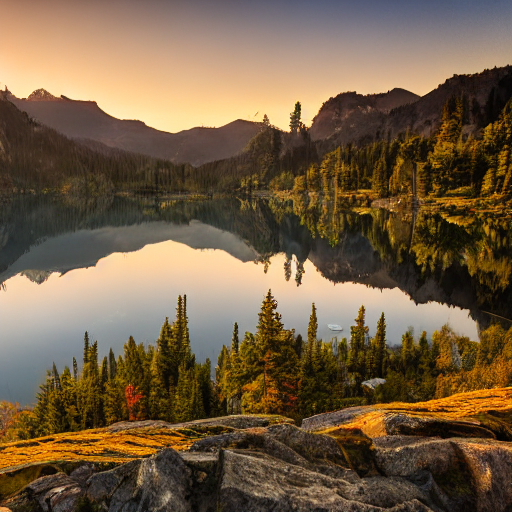

In [5]:
# Section 2.2 — First text-to-image generation
import time

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L01_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

prompt = "a serene mountain lake at sunrise, photorealistic, high detail"

generator = torch.Generator("cuda").manual_seed(SEED)

t0 = time.time()
result = pipe(prompt, generator=generator)
elapsed = time.time() - t0

image = result.images[0]
image.save(os.path.join(OUTPUT_DIR, "l01_first_image.png"))

print(f"Inference time: {elapsed:.1f} s")
print(f"NSFW flag: {result.nsfw_content_detected}")
image

**What do you observe?**  
- Does the image match your mental picture of the prompt?
- How long did inference take? Is this acceptable for practical use?

*Write your observation here:*

- cumple bastante mis espectativas, muy bello el paisaje
- casi 9 segundos, rapido para tiempo educativo

### Section 2.3 — `num_inference_steps`: quality vs. speed

The same seed and prompt — only the number of denoising steps changes. This lets us isolate the effect of this parameter.

  0%|          | 0/5 [00:00<?, ?it/s]

steps=  5  →  1.2 s


  0%|          | 0/15 [00:00<?, ?it/s]

steps= 15  →  2.4 s


  0%|          | 0/25 [00:00<?, ?it/s]

steps= 25  →  3.8 s


  0%|          | 0/50 [00:00<?, ?it/s]

steps= 50  →  7.3 s


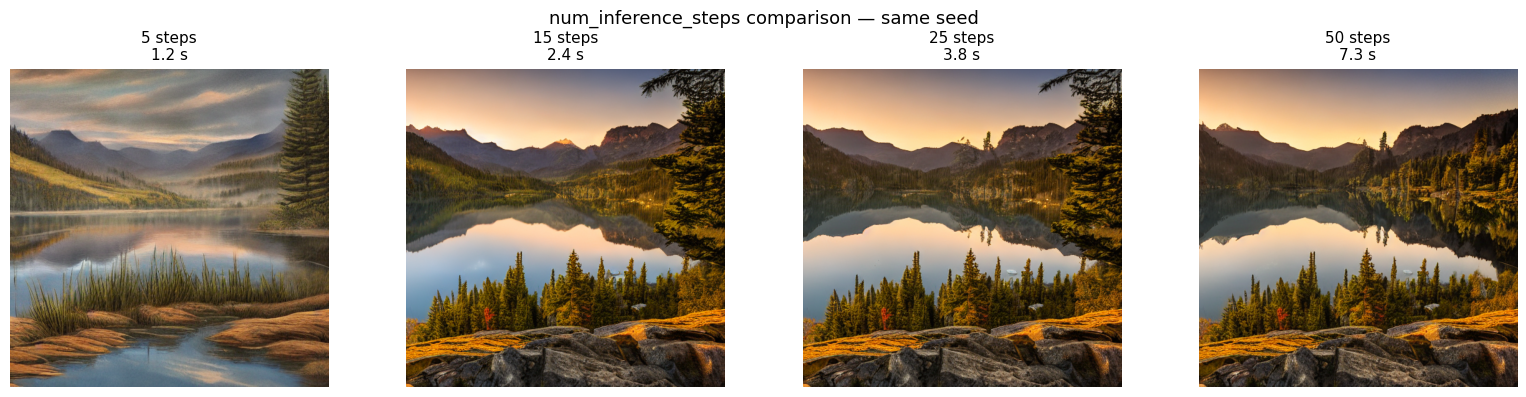

In [6]:
# Section 2.3 — Effect of num_inference_steps
import matplotlib.pyplot as plt

steps_to_test = [5, 15, 25, 50]
images_steps  = []
times_steps   = []

for steps in steps_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    t0  = time.time()
    img = pipe(prompt, num_inference_steps=steps, generator=gen).images[0]
    elapsed = time.time() - t0
    images_steps.append(img)
    times_steps.append(elapsed)
    print(f"steps={steps:3d}  →  {elapsed:.1f} s")

# Display side by side
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, steps, t in zip(axes, images_steps, steps_to_test, times_steps):
    ax.imshow(img)
    ax.set_title(f"{steps} steps\n{t:.1f} s", fontsize=11)
    ax.axis('off')
plt.suptitle("num_inference_steps comparison — same seed", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_steps_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At which step count does quality stop improving noticeably?
- Is the time increase proportional to the step increase?

*Write your observation here:*

- Apartir de los 15 pasos la imagen mejora en detalles bastante bien
- incrementa en tiempo casi linealmente

### Section 2.4 — `guidance_scale`: prompt adherence

`guidance_scale` (also called CFG scale) controls how strongly the UNet follows the prompt. Low values ignore it; very high values over-saturate and distort the image.

  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=1.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=5.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=7.5


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=12.0


  0%|          | 0/25 [00:00<?, ?it/s]

guidance_scale=20.0


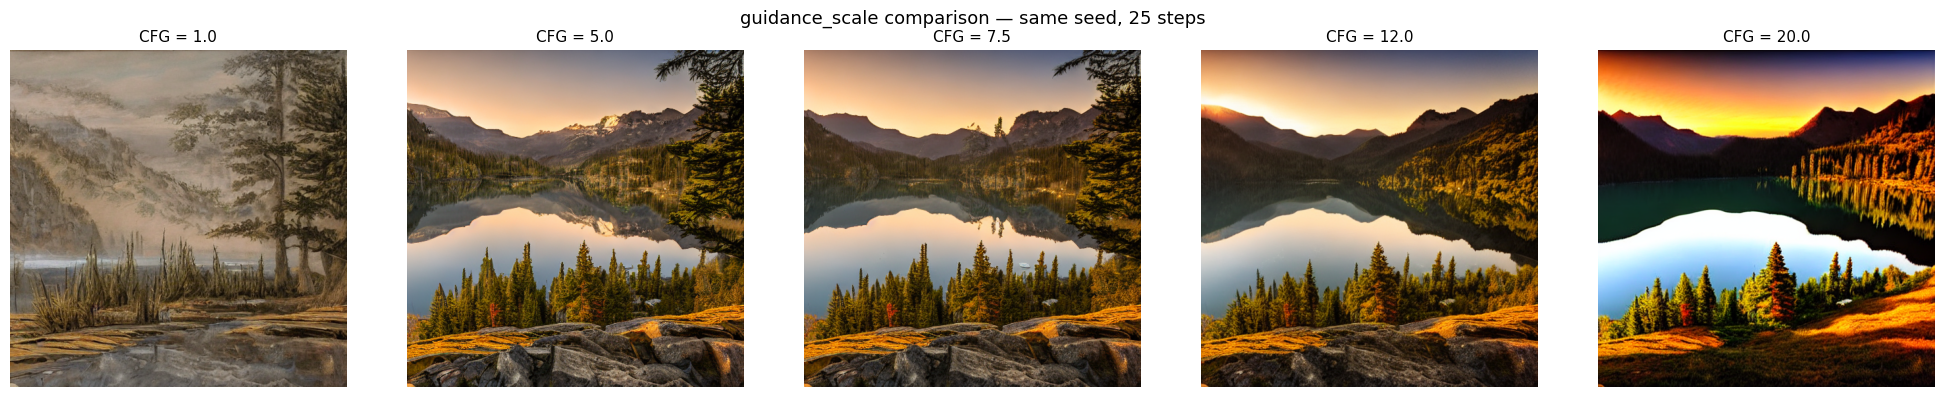

In [7]:
# Section 2.4 — Effect of guidance_scale
scales_to_test = [1.0, 5.0, 7.5, 12.0, 20.0]
images_cfg     = []

for scale in scales_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = pipe(
        prompt,
        num_inference_steps=25,
        guidance_scale=scale,
        generator=gen
    ).images[0]
    images_cfg.append(img)
    print(f"guidance_scale={scale}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img, scale in zip(axes, images_cfg, scales_to_test):
    ax.imshow(img)
    ax.set_title(f"CFG = {scale}", fontsize=11)
    ax.axis('off')
plt.suptitle("guidance_scale comparison — same seed, 25 steps", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "l01_cfg_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At what CFG value does the image start to degrade or look unnatural?
- Does a very low value (1.0) still produce a lake? Why or why not?

*Write your observation here:*

- Apartir de 20 es donde se ve poco natural, demasiado saturada la imagen
- Si, lo hace pero con colores tenues y tristes, dando la imagen de una imagen antigua, lo hace pq lo crea desde lo que sabe sin seguir tanto el promt


---
## Part 3 — Exercises

> Independent work. Use the code from Part 2 as your base.

### Exercise 1 — Prompt sensitivity

**Task:** Take the baseline prompt and change **one word** (an adjective, a setting, or an artistic style). Generate images for the original and the modified prompt using the same seed and the same parameters (25 steps, CFG 7.5). Display them side by side.

**Expected output:** A side-by-side figure with both images, titles showing which prompt produced each.

**Hint:** Try swapping `photorealistic` for `oil painting` or `serene` for `stormy`.

  0%|          | 0/25 [00:00<?, ?it/s]

prompt: original, CFG=7.5


  0%|          | 0/25 [00:00<?, ?it/s]

prompt: modified, CFG=7.5


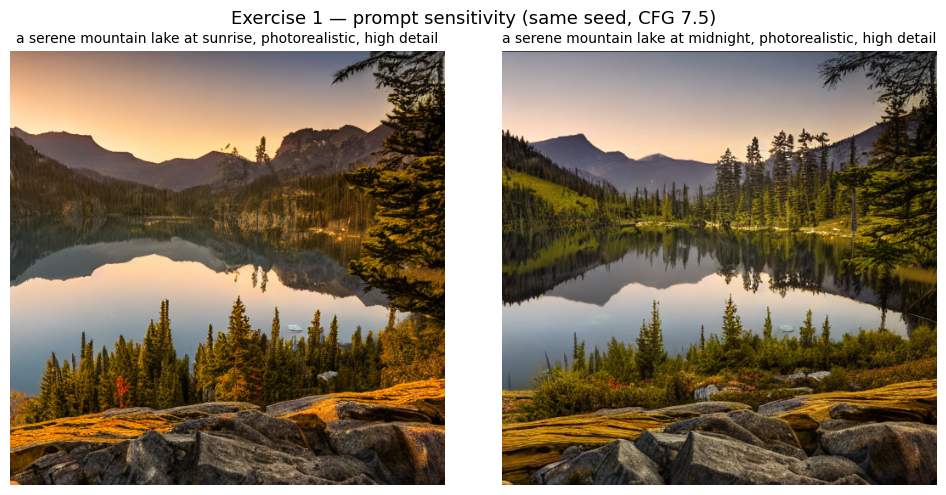

In [12]:
# Exercise 1 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
prompt_original = "a serene mountain lake at sunrise, photorealistic, high detail"
prompt_modified = "a serene mountain lake at midnight, photorealistic, high detail"  # change ONE word

# Generate both with the same seed
# ...
scales_to_test = [12.0]
images_cfg     = []

gen = torch.Generator("cuda").manual_seed(SEED)
img = pipe(
    prompt_original,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen
).images[0]
images_cfg.append(img)
print("prompt: original, CFG=7.5")

gen = torch.Generator("cuda").manual_seed(SEED)
img = pipe(
    prompt_modified,
    num_inference_steps=25,
    guidance_scale=7.5,
    generator=gen
).images[0]
images_cfg.append(img)
print("prompt: modified, CFG=7.5")

labels = [prompt_original, prompt_modified]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, img, label in zip(axes, images_cfg, labels):
    ax.imshow(img)
    ax.set_title(label, fontsize=10, wrap=True)
    ax.axis('off')
plt.suptitle("Exercise 1 — prompt sensitivity (same seed, CFG 7.5)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise1.png"), dpi=100)
plt.show()

### Exercise 2 — Find your preferred operating point

**Task:** Using your modified prompt from Exercise 1, find the combination of `num_inference_steps` and `guidance_scale` that you think produces the best result **for that specific prompt**. Generate at least 4 variants with different parameter combinations and justify your choice.

**Expected output:** At least 4 images with parameters labeled, and a markdown cell explaining which combination you chose and why.

  0%|          | 0/100 [00:00<?, ?it/s]

steps=100, CFG=20.0


  0%|          | 0/5 [00:00<?, ?it/s]

steps=5, CFG=1.0


  0%|          | 0/25 [00:00<?, ?it/s]

steps=25, CFG=10.0


  0%|          | 0/50 [00:00<?, ?it/s]

steps=50, CFG=12.0


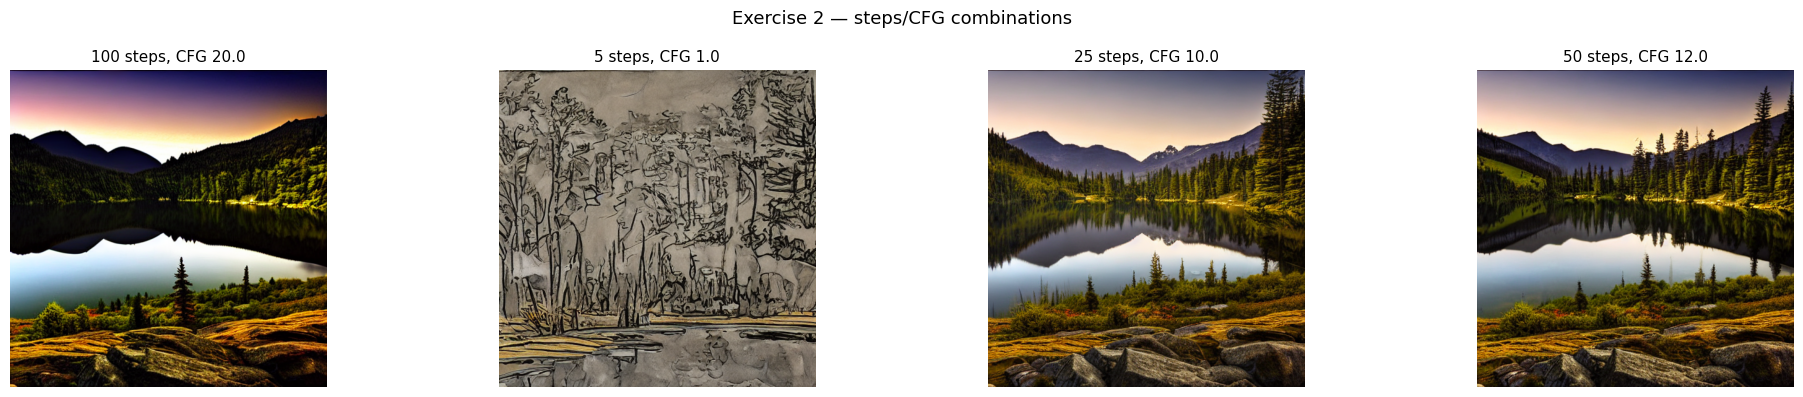

In [17]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# ...
# Exercise 2 -- your code here
prompt = prompt_modified  # tu prompt del Ejercicio 1

# Cada tupla es (num_inference_steps, guidance_scale)
combos_to_test = [
    (100, 20.0),
    (5, 1.0),
    (25, 10.0),
    (50, 12.0),
]

images_combos = []

for steps, cfg in combos_to_test:
    gen = torch.Generator("cuda").manual_seed(SEED)
    img = pipe(
        prompt,
        num_inference_steps=steps,
        guidance_scale=cfg,
        generator=gen
    ).images[0]
    images_combos.append(img)
    img.save(os.path.join(OUTPUT_DIR, f"exercise2_steps{steps}_cfg{cfg}.png"))
    print(f"steps={steps}, CFG={cfg}")

fig, axes = plt.subplots(1, len(combos_to_test), figsize=(20, 4))
for ax, img, (steps, cfg) in zip(axes, images_combos, combos_to_test):
    ax.imshow(img)
    ax.set_title(f"{steps} steps, CFG {cfg}", fontsize=11)
    ax.axis('off')
plt.suptitle("Exercise 2 — steps/CFG combinations", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2.png"), dpi=100)
plt.show()

*Your justification here (which combination you chose and why):*

- Las 3ra de enmedio fueron para asegurar un valor estandar
- las de los extremos fueron para ver que tanto se satura una imagen al momento incrementar los pasos y la escala
- Y la segunda poara ver que tan pobre podia llegar a ser la imagen si mantenia todo al minimo

---
## Part 4 — Critical Analysis

> Required. No code — documented reflection based on what you actually observed.
> Complete this **before closing the notebook**.

**4.1 — At what `num_inference_steps` value did quality stop improving noticeably? Show the images that support your answer.**

*Write here (reference your Section 2.3 output):*
La calidad deja de mejorar notablemente entre los 15 y 25 pasos (Sección 2.3); de 25 a 50 pasos las imágenes son casi idénticas, solo cuesta el doble de tiempo sin beneficio visible.
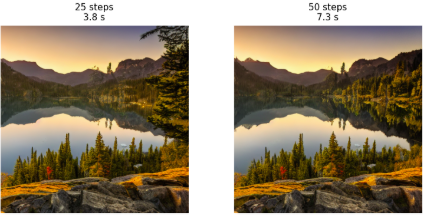

---

**4.2 — At what `guidance_scale` value did the image begin to degrade? Describe specifically what the degradation looked like (color saturation, anatomy, background artifacts…)**

*Write here (reference your Section 2.4 output):*
degradación clara empieza en CFG ≈ 12–20: en la Sección 2.4 y en el Ejercicio 2 se nota sobresaturación de color y una textura granulada/ruidosa que no aparece en CFG 7.5–10.
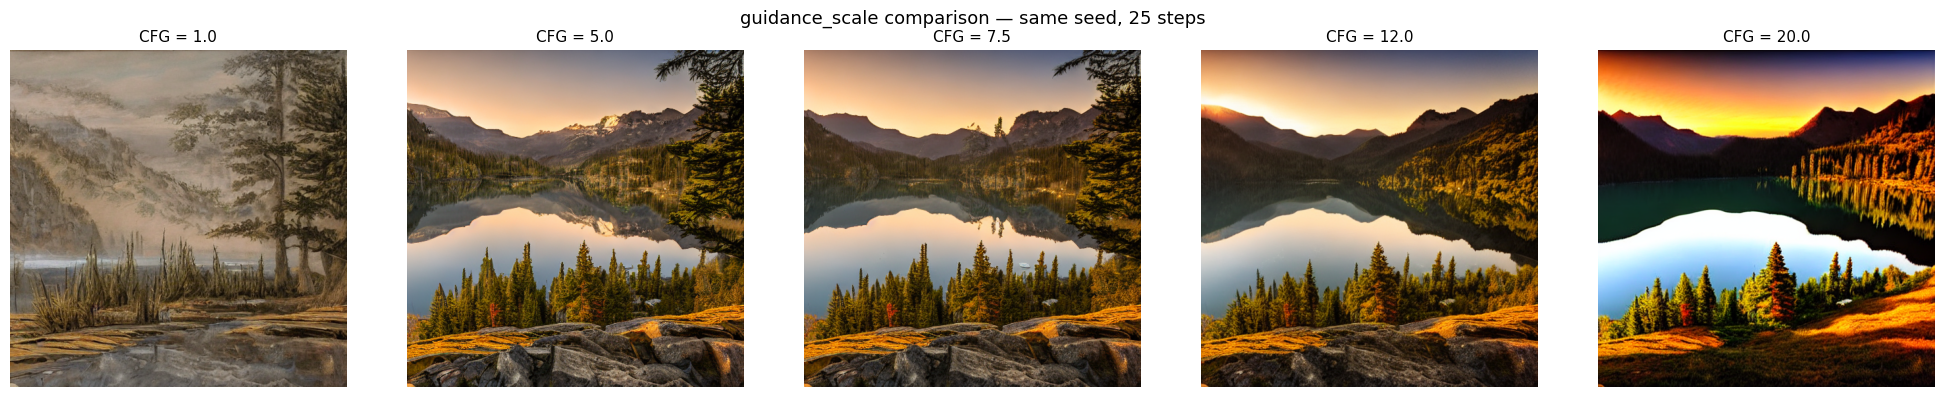
---

**4.3 — What real-world application would benefit most from the quality/speed trade-off you found in 4.1?**

*One concrete idea — not a generic answer:*
Un flujo de previsualización rápida en herramientas de diseño (por ejemplo, un editor donde el usuario prueba muchos prompts antes de decidir): usar 15 pasos para iterar rápido, y solo correr la versión final a 25-50 pasos una vez elegido el resultado.

---

**4.4 — What aspect of the pipeline (CLIP encoder, UNet, VAE, Scheduler) do you understand least after this lesson? What would you need to read or try to understand it better?**

lo que entiendo menos es cómo el Scheduler (PNDMScheduler) decide el tamaño de cada paso de denoising; para entenderlo mejor leería la documentación de diffusers sobre schedulers y probaría cambiarlo por DDIMScheduler para comparar resultados


---
## Part 5 — Ethical Considerations

> L01 covers image generation — this section is required.

**5.1 — Describe one realistic scenario in which this technology (text-to-image generation) could be used to cause harm.**

Alguien podría generar una imagen fotorrealista falsa de un político en un lugar o situación que nunca ocurrió, y difundirla en redes como "evidencia" para manipular opinión pública antes de una elección

---

**5.2 — The pipeline has a `safety_checker` that blocks certain outputs. What are the limits of this approach? Name at least one category of harmful content it would not catch.**

El safety_checker está entrenado principalmente para detectar contenido sexual/desnudez; no detecta desinformación o deepfakes de personas reales (una imagen totalmente "segura" visualmente puede ser igual de dañina si es un engaño creíble).


---

**5.3 — If you were deploying this model in a public web application, what one technical guardrail would you implement beyond the built-in safety checker?**

Implementar marca de agua invisible en cada imagen generada para que cualquier imagen producida por la app quede identificable como generada por IA, incluso si se recorta o comparte fuera de contexto.


---
## Submission Checklist

Before saving and sharing this notebook:

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.3 comparison figure saved (`l01_steps_comparison.png`)
- [ ] Section 2.4 comparison figure saved (`l01_cfg_comparison.png`)
- [ ] Exercise 1 — side-by-side comparison with two different prompts
- [ ] Exercise 2 — 4+ variants with chosen combination justified
- [ ] Part 4 — Critical Analysis completed (all 4 questions answered with real evidence)
- [ ] Part 5 — Ethics completed (all 3 questions)
- [ ] SD 1.5 weights saved to Google Drive (`TAE_IA_M6/models`)

**Save:** `File > Save a copy in Drive`

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L01*  
*Platform: Google Colab (T4 GPU) · Python 3.10*